In [1]:
import gymnasium as gym
import torch
import torch.optim as optim

from Reinforce import Policy
from Reinforce import reinforce
from Reinforce import evaluate_agent
from Reinforce import plot_reward
from Reinforce import render_callback

C:\Users\Philipp\AppData\Local\Programs\Python\Python313\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

env_id = "CartPole-v1"
env = gym.make(env_id)

eval_env = gym.make(env_id)

s_size = env.observation_space.shape[0]
a_size = env.action_space.n

In [3]:
print("OBSERVATION SPACE: ", s_size)
print("CTION SPACE: ", a_size)

_____OBSERVATION SPACE_____ 

The State Space is:  4

 _____ACTION SPACE_____ 

The Action Space is:  2


In [4]:
cartpole_hyperparameters = {
    "h_size": 16,
    "n_training_episodes": 500,
    "n_evaluation_episodes": 10,
    "max_t": 1000,
    "gamma": 1.0,
    "lr": 1e-2,
    "env_id": env_id,
    "state_space": s_size,
    "action_space": a_size,
}

cartpole_policy = Policy(cartpole_hyperparameters["state_space"], cartpole_hyperparameters["action_space"], cartpole_hyperparameters["h_size"]).to(device)
cartpole_optimizer = optim.Adam(cartpole_policy.parameters(), lr=cartpole_hyperparameters["lr"])

In [5]:
scores = reinforce(
    env,
    cartpole_policy,
    cartpole_optimizer,
    cartpole_hyperparameters["n_training_episodes"],
    cartpole_hyperparameters["max_t"],
    cartpole_hyperparameters["gamma"],
    100
)

Episode 100	Average Score: 55.73
Episode 200	Average Score: 222.42
Episode 300	Average Score: 412.01
Episode 400	Average Score: 431.31
Episode 500	Average Score: 449.01


In [6]:
evaluate_agent(
    eval_env,
    cartpole_hyperparameters["max_t"],
    cartpole_hyperparameters["n_evaluation_episodes"],
    cartpole_policy
)

(np.float64(1000.0), np.float64(0.0))

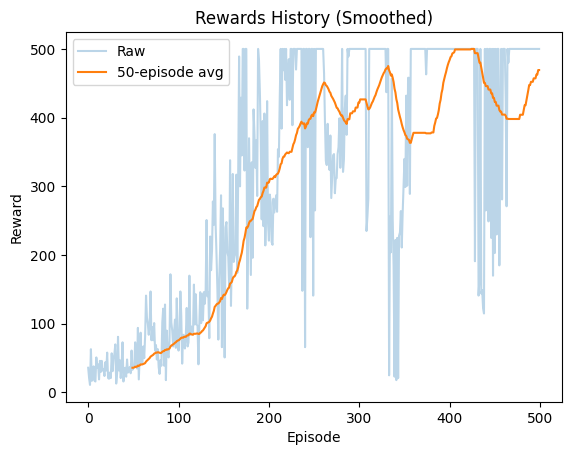

In [7]:
plot_reward(rewards=scores)

In [8]:
render_callback(cartpole_policy, env_id)